# Exploración de datos — Riesgo crediticio (Entrega 1)

**Dataset:** *Give Me Some Credit* (`cs-training.csv`)</br>
**Target:** `SeriousDlqin2yrs`</br>
**Pregunta de negocio:** ¿cuál es la probabilidad de incumplimiento grave (mora ≥ 90 días) a 2 años de un solicitante, y cómo usarla para segmentar la aprobación?

## 0. Carga de librerias y de datos

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

RUTA = "../data/raw/cs-training.csv"
df = pd.read_csv(RUTA, index_col=0)

# Nombres más manejables (guardamos el mapeo para el reporte)
df = df.rename(columns={
    "SeriousDlqin2yrs": "incumplio",
    "RevolvingUtilizationOfUnsecuredLines": "utilizacion",
    "age": "edad",
    "NumberOfTime30-59DaysPastDueNotWorse": "moras_30_59",
    "DebtRatio": "razon_deuda",
    "MonthlyIncome": "ingreso_mensual",
    "NumberOfOpenCreditLinesAndLoans": "lineas_abiertas",
    "NumberOfTimes90DaysLate": "moras_90",
    "NumberRealEstateLoansOrLines": "creditos_inmob",
    "NumberOfTime60-89DaysPastDueNotWorse": "moras_60_89",
    "NumberOfDependents": "dependientes",
})
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 150,000 | Columnas: 11


,incumplio,utilizacion,edad,moras_30_59,razon_deuda,ingreso_mensual,lineas_abiertas,moras_90,creditos_inmob,moras_60_89,dependientes
Id,,,,,,,,,,,
1,1,0.77,45,2,0.80,"9,120.00",13,0,6,0,2.00
2,0,0.96,40,0,0.12,"2,600.00",4,0,0,0,1.00
3,0,0.66,38,1,0.09,"3,042.00",2,1,0,0,0.00
4,0,0.23,30,0,0.04,"3,300.00",5,0,0,0,0.00
5,0,0.91,49,1,0.02,"63,588.00",7,0,1,0,0.00


## 1. Estructura general

Una fila corresponde a **un cliente** observado en un punto del tiempo, con su situación y comportamiento crediticio histórico y el resultado de incumplimiento (mora grave sí/no) en los 2 años siguientes. Es un problema de clasificación binaria supervisada clásico de *credit scoring*.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   incumplio        150000 non-null  int64  
 1   utilizacion      150000 non-null  float64
 2   edad             150000 non-null  int64  
 3   moras_30_59      150000 non-null  int64  
 4   razon_deuda      150000 non-null  float64
 5   ingreso_mensual  120269 non-null  float64
 6   lineas_abiertas  150000 non-null  int64  
 7   moras_90         150000 non-null  int64  
 8   creditos_inmob   150000 non-null  int64  
 9   moras_60_89      150000 non-null  int64  
 10  dependientes     146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
incumplio,"150,000.00",0.07,0.25,0.00,0.00,0.00,0.00,1.00
utilizacion,"150,000.00",6.05,249.76,0.00,0.03,0.15,0.56,"50,708.00"
edad,"150,000.00",52.30,14.77,0.00,41.00,52.00,63.00,109.00
moras_30_59,"150,000.00",0.42,4.19,0.00,0.00,0.00,0.00,98.00
razon_deuda,"150,000.00",353.01,"2,037.82",0.00,0.18,0.37,0.87,"329,664.00"
ingreso_mensual,"120,269.00","6,670.22","14,384.67",0.00,"3,400.00","5,400.00","8,249.00","3,008,750.00"
lineas_abiertas,"150,000.00",8.45,5.15,0.00,5.00,8.00,11.00,58.00
moras_90,"150,000.00",0.27,4.17,0.00,0.00,0.00,0.00,98.00
creditos_inmob,"150,000.00",1.02,1.13,0.00,0.00,1.00,2.00,54.00
moras_60_89,"150,000.00",0.24,4.16,0.00,0.00,0.00,0.00,98.00


Se evidencia un mínimo de Edad (0), se analizará ocurrencia porque no corresponde a una edad mínima aceptable.  Utilizacion y Razon_deuda presentan valores máximo extremadamente altos, lejos de sus medianas (¿miles cuando deberían ser proporciones?) estas variables están expresadas como cocientes. 

## 2. Calidad de datos

In [7]:
# 2.1 Valores faltantes
faltantes = (df.isna().sum().to_frame("n_faltantes")
             .assign(pct=lambda d: 100 * d.n_faltantes / len(df))
             .query("n_faltantes > 0").sort_values("pct", ascending=False))
faltantes

,n_faltantes,pct
ingreso_mensual,29731,19.82
dependientes,3924,2.62


In [8]:
# 2.2 Duplicados
print(f"Filas duplicadas exactas: {df.duplicated().sum():,}")

Filas duplicadas exactas: 609


In [9]:
# 2.3 Valores imposibles y centinelas
print(f"Registros con edad <= 0: {(df.edad <= 0).sum()}")
print(f"Registros con utilizacion > 1: {(df.utilizacion > 1).sum():,} "
      f"({100*(df.utilizacion > 1).mean():.2f}%)")
print(f"Registros con utilizacion > 10: {(df.utilizacion > 10).sum():,}")

for c in ["moras_30_59", "moras_60_89", "moras_90"]:
    n = df[c].isin([96, 98]).sum()
    print(f"Centinelas 96/98 en {c}: {n:,} ({100*n/len(df):.2f}%)")

# ¿Son los mismos registros? (sospecha: sí)
mask_cent = df[["moras_30_59", "moras_60_89", "moras_90"]].isin([96, 98]).any(axis=1)
print(f"\nRegistros con algún centinela: {mask_cent.sum():,}")
print(f"Tasa de incumplimiento en esos registros: {100*df.loc[mask_cent, 'incumplio'].mean():.1f}% "
      f"(vs {100*df.incumplio.mean():.1f}% global)")

Registros con edad <= 0: 1
Registros con utilizacion > 1: 3,321 (2.21%)
Registros con utilizacion > 10: 241
Centinelas 96/98 en moras_30_59: 269 (0.18%)
Centinelas 96/98 en moras_60_89: 269 (0.18%)
Centinelas 96/98 en moras_90: 269 (0.18%)

Registros con algún centinela: 269
Tasa de incumplimiento en esos registros: 54.6% (vs 6.7% global)


In [10]:
# 2.4 ¿El faltante de ingreso es informativo?
tasa_con = df.loc[df.ingreso_mensual.notna(), "incumplio"].mean()
tasa_sin = df.loc[df.ingreso_mensual.isna(), "incumplio"].mean()
print(f"Tasa de incumplimiento CON ingreso reportado: {100*tasa_con:.2f}%")
print(f"Tasa de incumplimiento SIN ingreso reportado: {100*tasa_sin:.2f}%")
# Relación entre ingreso faltante y razon_deuda extrema
df.groupby(df.ingreso_mensual.isna())["razon_deuda"].describe()

Tasa de incumplimiento CON ingreso reportado: 6.95%
Tasa de incumplimiento SIN ingreso reportado: 5.61%


,count,mean,std,min,25%,50%,75%,max
ingreso_mensual,,,,,,,,
False,"120,269.00",26.60,424.45,0.00,0.14,0.30,0.48,"61,106.50"
True,"29,731.00","1,673.40","4,248.37",0.00,123.00,"1,159.00","2,382.00","329,664.00"


El dataset presenta cuatro problemas de calidad con decisiones asociadas: </br>(1) ~20% de faltantes en `ingreso_mensual`: el faltante parece correlacionado con valores atipicos de `razon_deuda`, por lo que imputaremos con mediana y añadiremos un indicador binario de faltante como variable </br>(2) Valores centinela 96/98 en las variables de mora, concentrados en los mismos registros y con tasa de incumplimiento altísima — los trataremos como categoría propia de "moroso crónico" en lugar de eliminarlos, porque son señal, no ruido; </br>(3) Un registro con edad 0, que eliminaremos </br>(4) `utilizacion` con valores extremos que seran estudiados a través de la técnica winsor por encima del percentil 99.

## 3. Variable objetivo y balance de clases

Con esta gráfica se determina las métricas del proyecto

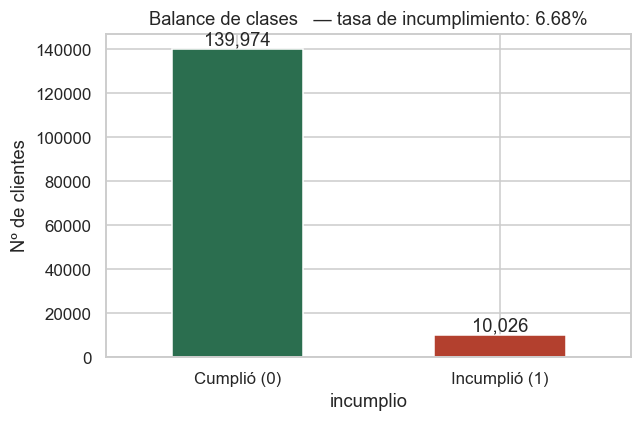

In [11]:
tasa = df.incumplio.mean()
fig, ax = plt.subplots(figsize=(6, 4))
df.incumplio.value_counts().sort_index().plot(kind="bar", ax=ax,
    color=["#2b6e4f", "#b3402e"], rot=0)
ax.set_xticklabels(["Cumplió (0)", "Incumplió (1)"])
ax.set_ylabel("Nº de clientes")
ax.set_title(f"Balance de clases   — tasa de incumplimiento: {100*tasa:.2f}%")
for i, v in enumerate(df.incumplio.value_counts().sort_index()):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); 
plt.show()

Aproximadamente solo 1 de cada 15 clientes incumple aproximadamente 6,7%. Implicaciones directas para el proyecto: (i) el accuracy es una métrica inútil aquí puesto que un modelo que apruebe a todos acierta aproximadamnte 93% sin servir para nada; evaluaremos con AUC-ROC, AUC-PR y recall a precisión fija; (ii) probaremos estrategias de manejo de desbalance (ponderación de clases vs. remuestreo); (iii) el umbral de decisión no será 0,5 sino el que minimice el costo esperado, esto debido a que un falso negativo (aprobar a quien no paga) cuesta  capital y un falso positivo solo el margen

## 4. Análisis univariado

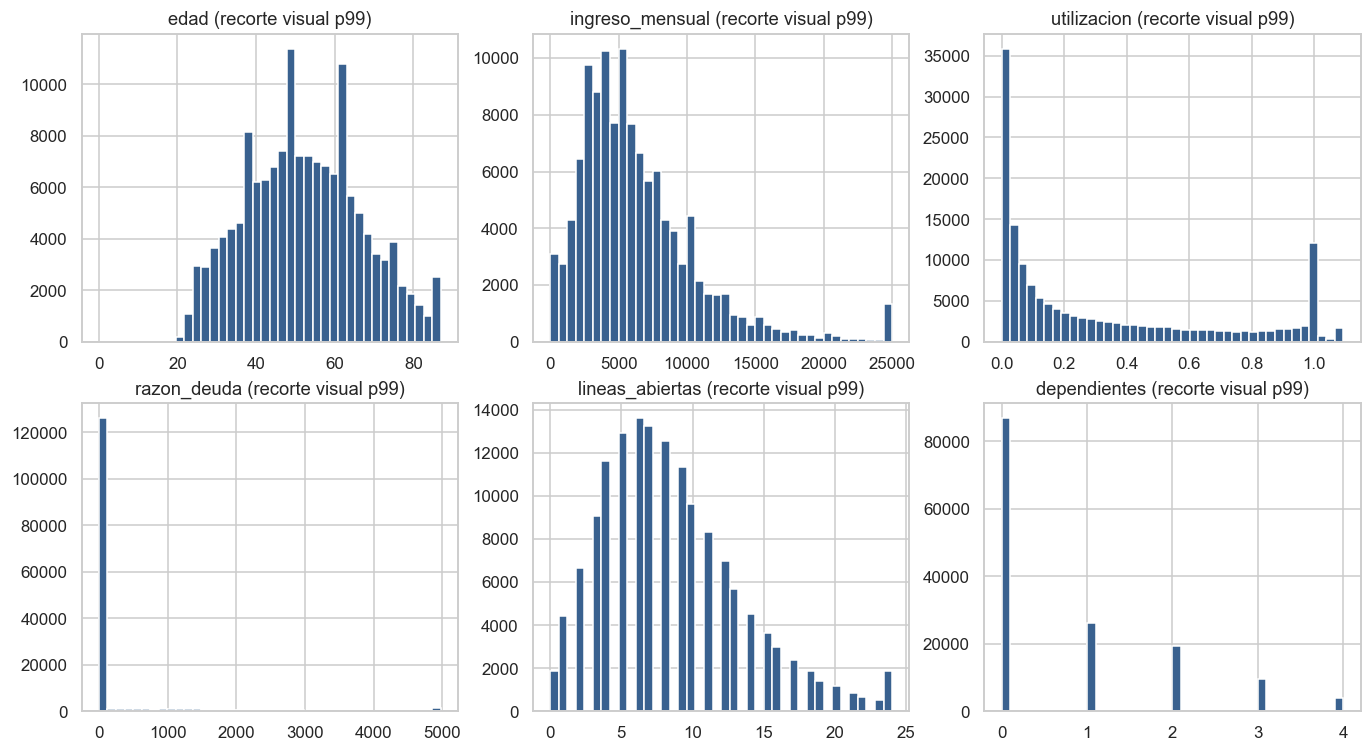

In [12]:
vars_num = ["edad", "ingreso_mensual", "utilizacion", "razon_deuda",
            "lineas_abiertas", "dependientes"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), vars_num):
    s = df[c].dropna()
    # recorte visual al p99 para que la cola no aplaste la distribución
    s.clip(upper=s.quantile(0.99)).hist(bins=40, ax=ax, color="#39618f")
    ax.set_title(f"{c} (recorte visual p99)")
plt.show()

## 5. Relación con el incumplimiento (bivariado)

Núcleo del EDA: cada gráfica debe responder "¿esta variable separa a los que incumplen de los que no?".

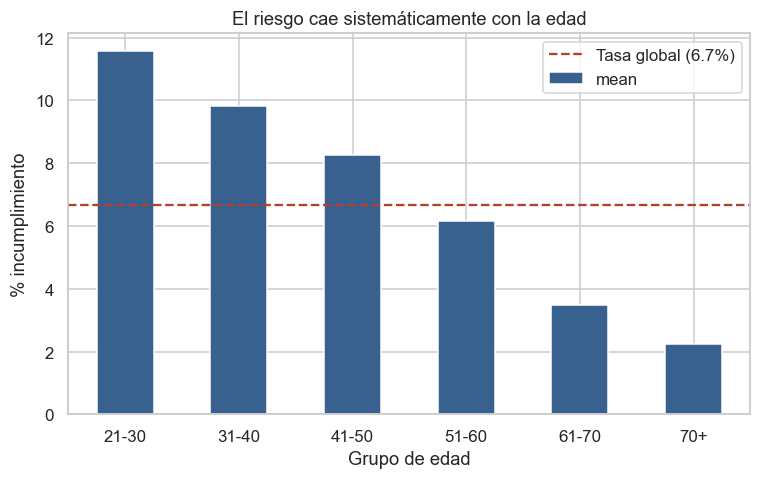

,mean,count
grupo_edad,,
21-30,0.12,10757
31-40,0.10,24339
41-50,0.08,35037
51-60,0.06,34806
61-70,0.03,27424
70+,0.02,17636


In [13]:
# 5.1 Tasa de incumplimiento por grupo de edad
df["grupo_edad"] = pd.cut(df.edad, bins=[20, 30, 40, 50, 60, 70, 110],
                          labels=["21-30", "31-40", "41-50", "51-60", "61-70", "70+"])
tasa_edad = df.groupby("grupo_edad", observed=True).incumplio.agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(8, 4.5))
(100 * tasa_edad["mean"]).plot(kind="bar", ax=ax, color="#39618f", rot=0)
ax.axhline(100 * tasa, ls="--", color="#b3402e", label=f"Tasa global ({100*tasa:.1f}%)")
ax.set_ylabel("% incumplimiento"); ax.set_xlabel("Grupo de edad")
ax.set_title("El riesgo cae sistemáticamente con la edad"); ax.legend()
plt.show()
tasa_edad

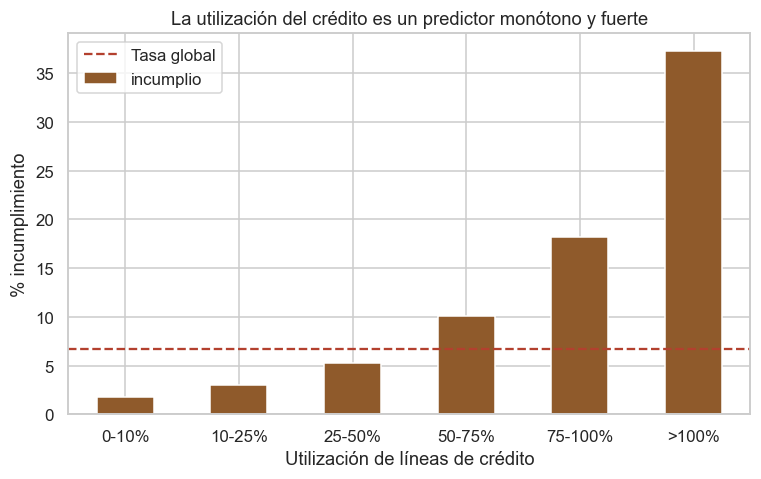

In [14]:
# 5.2 Tasa de incumplimiento por tramo de utilización del crédito
bins_util = [0, 0.1, 0.25, 0.5, 0.75, 1.0, np.inf]
labels_util = ["0-10%", "10-25%", "25-50%", "50-75%", "75-100%", ">100%"]
df["tramo_util"] = pd.cut(df.utilizacion, bins=bins_util, labels=labels_util, include_lowest=True)
tasa_util = df.groupby("tramo_util", observed=True).incumplio.mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
(100 * tasa_util).plot(kind="bar", ax=ax, color="#8f5a2b", rot=0)
ax.axhline(100 * tasa, ls="--", color="#b3402e", label="Tasa global")
ax.set_ylabel("% incumplimiento"); ax.set_xlabel("Utilización de líneas de crédito")
ax.set_title("La utilización del crédito es un predictor monótono y fuerte"); ax.legend()
plt.show()

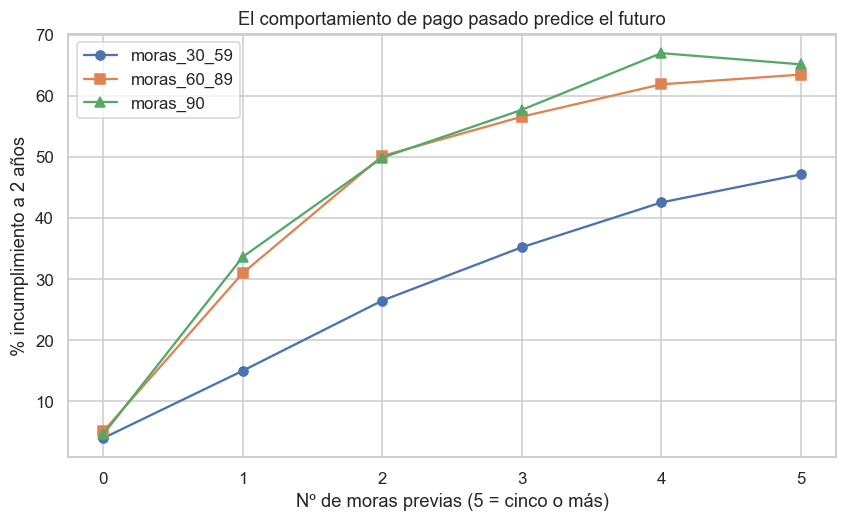

In [15]:
# 5.3 Historial de moras previas vs incumplimiento futuro (la señal más fuerte)
def tasa_por_conteo(col):
    d = df[~df[col].isin([96, 98])].copy()
    d[col] = d[col].clip(upper=5)  # 5+ agrupado
    return d.groupby(col).incumplio.mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
for col, marker in [("moras_30_59", "o"), ("moras_60_89", "s"), ("moras_90", "^")]:
    tasa_por_conteo(col).plot(ax=ax, marker=marker, label=col)
ax.set_xlabel("Nº de moras previas (5 = cinco o más)")
ax.set_ylabel("% incumplimiento a 2 años")
ax.set_title("El comportamiento de pago pasado predice el futuro")
ax.legend()
plt.show()

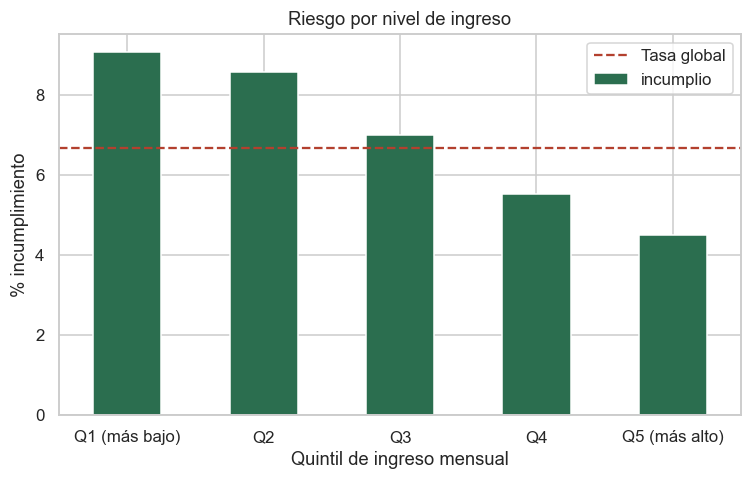

In [16]:
# 5.4 Ingreso y riesgo
df["tramo_ingreso"] = pd.qcut(df.ingreso_mensual, q=5,
    labels=["Q1 (más bajo)", "Q2", "Q3", "Q4", "Q5 (más alto)"])
tasa_ing = df.groupby("tramo_ingreso", observed=True).incumplio.mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
(100 * tasa_ing).plot(kind="bar", ax=ax, color="#2b6e4f", rot=0)
ax.axhline(100 * tasa, ls="--", color="#b3402e", label="Tasa global")
ax.set_ylabel("% incumplimiento"); ax.set_xlabel("Quintil de ingreso mensual")
ax.set_title("Riesgo por nivel de ingreso"); ax.legend()
plt.show()

las variables con mayor poder de separación son, en orden: (i) el **historial de moras previas** — la tasa de incumplimiento se multiplica varias veces con cada mora adicional, confirmando que el comportamiento pasado es el mejor predictor del futuro; (ii) la **utilización de las líneas de crédito**, con relación monótona: clientes usando >75% de su cupo incumplen varias veces más que quienes usan <10%; (iii) la **edad**, con riesgo decreciente; (iv) el **ingreso**, con efecto más moderado de lo que la intuición sugiere. Esto anticipa que los ensambles de árboles capturarán bien estas no-linealidades, y define los filtros y visualizaciones del tablero descriptivo.

## 6. Correlaciones

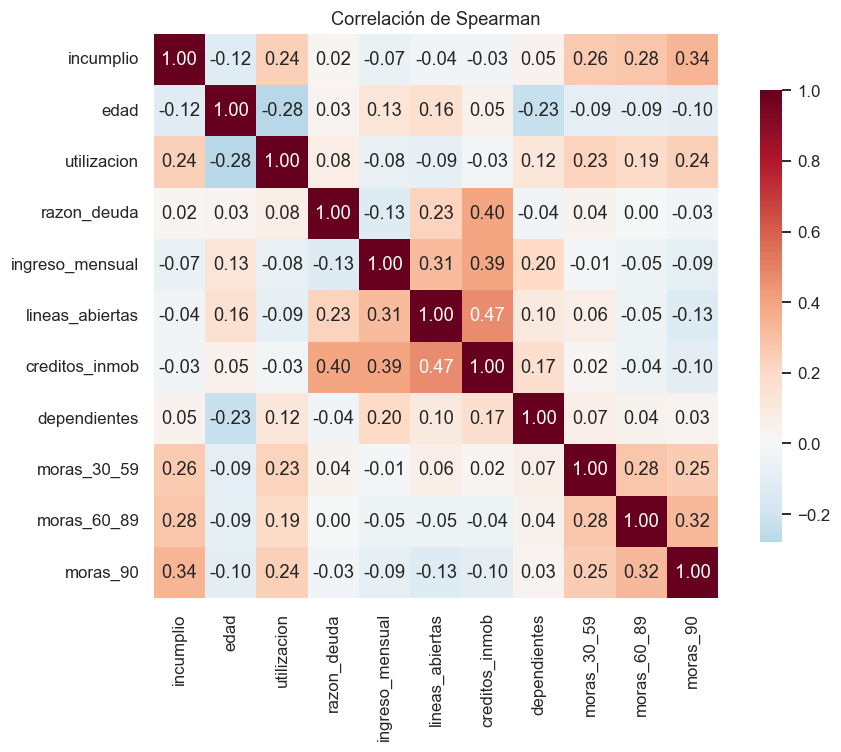

In [18]:
corr = df[["incumplio", "edad", "utilizacion", "razon_deuda", "ingreso_mensual",
           "lineas_abiertas", "creditos_inmob", "dependientes",
           "moras_30_59", "moras_60_89", "moras_90"]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlación de Spearman")
plt.tight_layout(); plt.savefig("../docs/fig_correlaciones.png", bbox_inches="tight")
plt.show()

1. Factores con mayor impacto en el incumplimiento (incumplio)

Historial de moras: Es el predictor más directo del impago. A mayor tiempo de atraso en pagos pasados, mayor probabilidad de volver a incumplir:

moras_90 (0.34): Tener retrasos mayores a 90 días es la variable con más peso.

moras_60_89 (0.28) y moras_30_59 (0.26).

Utilización del crédito (utilizacion = 0.24): A medida que la persona satura sus límites de crédito (usa más cupo disponible), aumenta su riesgo de mora.

Edad (edad = -0.12): Relación negativa moderada; a mayor edad del cliente, disminuye levemente la probabilidad de incumplimiento (los clientes más jóvenes presentan ligeramente mayor riesgo).

2. Relaciones clave entre variables explicativas

Capacidad transaccional e infraestructura:

creditos_inmob con lineas_abiertas (0.47), razon_deuda (0.40) e ingreso_mensual (0.39): Personas con créditos hipotecarios tienden a manejar más tarjetas/créditos, ingresos más altos y mayor nivel de endeudamiento global.

Estructura socioeconómica:

ingreso_mensual con lineas_abiertas (0.31): A mayor ingreso, las entidades otorgan más productos crediticios.

edad con utilizacion (-0.28) y dependientes (-0.23): Clientes mayores tienden a saturar menos sus tarjetas de crédito y tienen menos dependientes a su cargo.

## 7. Conclusiones e implicaciones

1. El comportamiento histórico de pago es un indicador clave del riesgo crediticio. Las variables relacionadas con las moras de 30–59, 60–89 y 90 días permiten identificar patrones diferenciadores de los clientes y aportan información relevante para estimar la probabilidad de incumplimiento futuro. En particular, los registros asociados a comportamientos de mora presentan una concentración significativamente mayor de incumplimientos, lo que confirma su valor predictivo para el modelo.

2. La utilización del crédito constituye una variable relevante para caracterizar el perfil financiero del cliente. El análisis de utilizacion permite incorporar al modelo información sobre el nivel de uso de las líneas de crédito disponibles, proporcionando una perspectiva adicional sobre el comportamiento financiero y la exposición crediticia del solicitante.

3. La relación entre obligaciones e ingresos aporta una perspectiva importante sobre la capacidad financiera. Variables como razon_deuda e ingreso_mensual permiten analizar conjuntamente el nivel de endeudamiento y los recursos disponibles del cliente. Esta combinación puede contribuir a diferenciar perfiles con diferentes niveles de capacidad de pago y, por tanto, fortalecer la evaluación del riesgo.

4. Las características demográficas y de estructura crediticia complementan la evaluación del riesgo. Variables como edad, lineas_abiertas, creditos_inmob y dependientes permiten construir una visión más completa del perfil del solicitante. Su incorporación junto con las variables de comportamiento financiero permite que el modelo no dependa de un único indicador, sino que considere diferentes dimensiones del riesgo crediticio.

5. El análisis exploratorio permite establecer una base sólida para construir un modelo de scoring orientado a la toma de decisiones. La identificación de patrones en comportamiento de pago, utilización del crédito, endeudamiento, ingresos y características del cliente permite seleccionar y transformar las variables de manera fundamentada. Esto facilita desarrollar posteriormente un modelo capaz de estimar la probabilidad de incumplimiento y apoyar estrategias de segmentación y aprobación crediticia.